# 03 — Feature selection: top 40 of 77 by SVM-RFE — CSE-CIC-IDS2018

Features are selected by **Recursive Feature Elimination around the study's linear SVM** (Guyon et al., 2002). A wrapper method: the SVM is fitted repeatedly, each round dropping the features with the smallest coefficient magnitudes, until 40 remain.

Fitted on the *training side of the stratified 70/30 split only* — the test side never
influences selection (no leakage). The resulting top-40 set is **frozen and reused by
every split scheme** in notebook 04. Selection runs on a class-proportional subsample
(`SAMPLE_ROWS`) of the training portion; rare classes are never dropped.

In [1]:
DATASET = "cic2018"
FT_ROOT = "ft40_rfe"
TOP_K = 40
RFE_STEP = 5
SAMPLE_ROWS = 300_000

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import nb_common as nbc
from ids import config
from ids.schema import CANONICAL_COLUMNS
from ids.features.rfe import rank_by_svm_rfe

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "03_feature_selection.log", "nb03")

with nbc.timed(log, "load clean.parquet"):
    df = pd.read_parquet(P.data / "clean.parquet")
X, y = df[CANONICAL_COLUMNS], df["y"].to_numpy()
log.info("%d rows, %d features, %d classes", len(X), X.shape[1], len(np.unique(y)))

2026-07-06 11:19:52,903 INFO nb03: START load clean.parquet
2026-07-06 11:19:54,768 INFO nb03: END   load clean.parquet (1.9s)
2026-07-06 11:19:56,066 INFO nb03: 1586902 rows, 77 features, 15 classes


## 1. Stratified 70/30 split (indices saved — reused as the `70_30` scheme)

In [3]:
idx = np.arange(len(X))
train_idx, test_idx = train_test_split(
    idx, test_size=0.30, stratify=y, random_state=config.RANDOM_STATE)
np.savez_compressed(P.splits / "70_30_indices.npz", train_idx=train_idx, test_idx=test_idx)
log.info("70/30 split: %d train / %d test (stratified, seed=%d)",
         len(train_idx), len(test_idx), config.RANDOM_STATE)

2026-07-06 11:20:01,126 INFO nb03: 70/30 split: 1110831 train / 476071 test (stratified, seed=42)


## 2. Recursive elimination around the linear SVM (drop weakest `RFE_STEP` per round)

In [4]:
with nbc.timed(log, f"SVM-RFE (subsample of {len(train_idx)} training rows)"):
    rank_df = rank_by_svm_rfe(X.iloc[train_idx], y[train_idx],
                              n_select=TOP_K, step=RFE_STEP, sample_rows=SAMPLE_ROWS)
rank_df.insert(0, "rank", range(1, len(rank_df) + 1))
rank_df.to_csv(P.features / "importance_ranking.csv", index=False)
rank_df.head(15)

2026-07-06 11:20:01,141 INFO nb03: START SVM-RFE (subsample of 1110831 training rows)
2026-07-06 11:20:02,819 INFO ids.features.subsample: stratified subsample: 1110831 -> 300005 rows (15 classes preserved)
2026-07-06 11:20:04,151 INFO ids.features.rfe: SVM-RFE on 300005 rows x 77 features (step=5, target=40)
2026-07-06 11:21:34,729 INFO nb03: END   SVM-RFE (subsample of 1110831 training rows) (93.6s)


,rank,feature,selected,rfe_rank,coef_mag
0,1,fwd_seg_size_min,True,1,5.235988
1,2,dst_port,True,1,3.873953
2,3,rst_flag_cnt,True,1,3.599948
3,4,ece_flag_cnt,True,1,3.599714
4,5,ack_flag_cnt,True,1,3.195806
5,6,init_bwd_win_byts,True,1,3.106827
6,7,bwd_pkt_len_min,True,1,3.083736
7,8,totlen_fwd_pkts,True,1,3.069651
8,9,subflow_fwd_byts,True,1,3.069651
9,10,fwd_act_data_pkts,True,1,2.970754


## 3. Freeze the top 40 (RFE survivors, ordered by final |coefficient|)

2026-07-06 11:21:34,756 INFO nb03: top 40 by SVM-RFE frozen


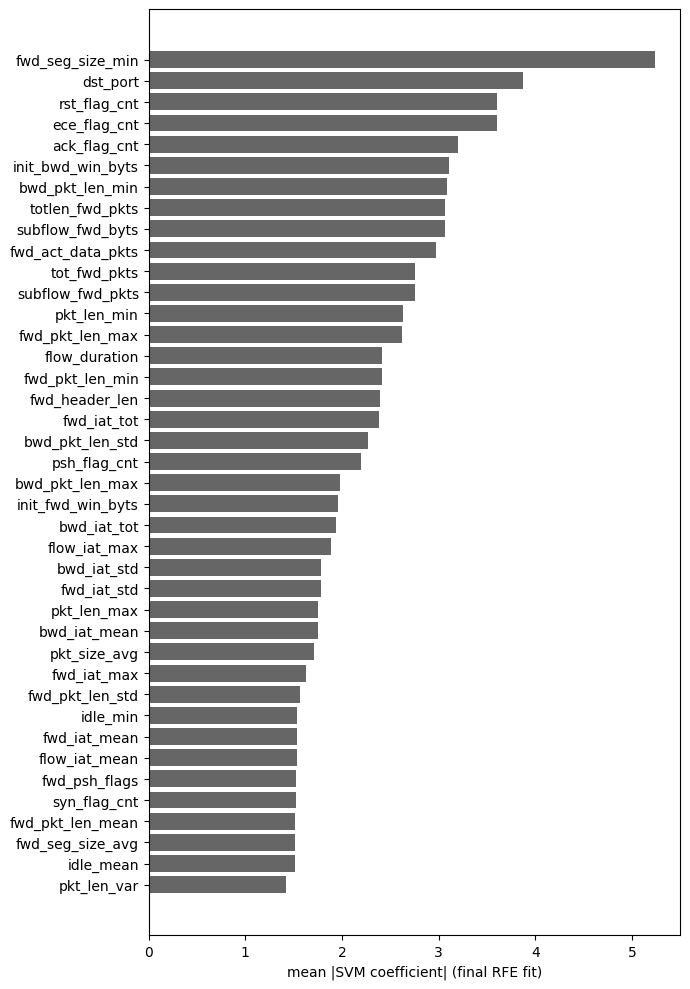

['fwd_seg_size_min',
 'dst_port',
 'rst_flag_cnt',
 'ece_flag_cnt',
 'ack_flag_cnt',
 'init_bwd_win_byts',
 'bwd_pkt_len_min',
 'totlen_fwd_pkts',
 'subflow_fwd_byts',
 'fwd_act_data_pkts',
 'tot_fwd_pkts',
 'subflow_fwd_pkts',
 'pkt_len_min',
 'fwd_pkt_len_max',
 'flow_duration',
 'fwd_pkt_len_min',
 'fwd_header_len',
 'fwd_iat_tot',
 'bwd_pkt_len_std',
 'psh_flag_cnt',
 'bwd_pkt_len_max',
 'init_fwd_win_byts',
 'bwd_iat_tot',
 'flow_iat_max',
 'bwd_iat_std',
 'fwd_iat_std',
 'pkt_len_max',
 'bwd_iat_mean',
 'pkt_size_avg',
 'fwd_iat_max',
 'fwd_pkt_len_std',
 'idle_min',
 'fwd_iat_mean',
 'flow_iat_mean',
 'fwd_psh_flags',
 'syn_flag_cnt',
 'fwd_pkt_len_mean',
 'fwd_seg_size_avg',
 'idle_mean',
 'pkt_len_var']

In [5]:
top40 = rank_df[rank_df["selected"]]["feature"].tolist()
assert len(top40) == TOP_K
nbc.save_json({
    "dataset": DATASET,
    "method": "svm_rfe",
    "k": TOP_K,
    "selected": top40,
    "rfe_step": RFE_STEP,
    "sample_rows": SAMPLE_ROWS,
    "fitted_on": "train side of the stratified 70/30 split only (no test leakage)",
    "random_state": config.RANDOM_STATE,
}, P.features / "top40.json")
log.info("top %d by SVM-RFE frozen", TOP_K)

fig, ax = plt.subplots(figsize=(7, 10))
head = rank_df.head(TOP_K).iloc[::-1]
ax.barh(head["feature"], head["coef_mag"], color="0.4")
ax.set_xlabel("mean |SVM coefficient| (final RFE fit)")
fig.tight_layout()
fig.savefig(P.features / "top40_importance.png", dpi=150)
plt.show()
top40